# Exploratory Data Analysis

This notebook revisits `01_data_understanding.ipynb` visually, now on the *cleaned* data from `02_data_preparation.ipynb`, and investigates the single most important finding so far: 84.2% of benign rows are DLLs but only 8.8% of malicious rows are, a shortcut a model could exploit ("not a DLL -> malicious") instead of learning genuine malware behaviour. A diagnostic model is trained here specifically to test whether that shortcut alone can explain a high accuracy score, this is a data-quality check, not model selection, which happens in `04_modelling_classical.ipynb` and `05_modelling_mlp.ipynb`.

In [11]:
# Standard library
import sys

# Third-party
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
sys.path.append("../src")

from constants import ORDER_OF_FEATURES, CORE_TRAITS, LABEL_COLUMN, RANDOM_STATE

## Load the Cleaned Dataset

In [12]:
df = pd.read_csv("../data/dataset_cleaned.csv")
print(df.shape)

(16627, 79)


16,627 rows and 79 columns, matching `02_data_preparation.ipynb`'s saved output.

## Class Balance

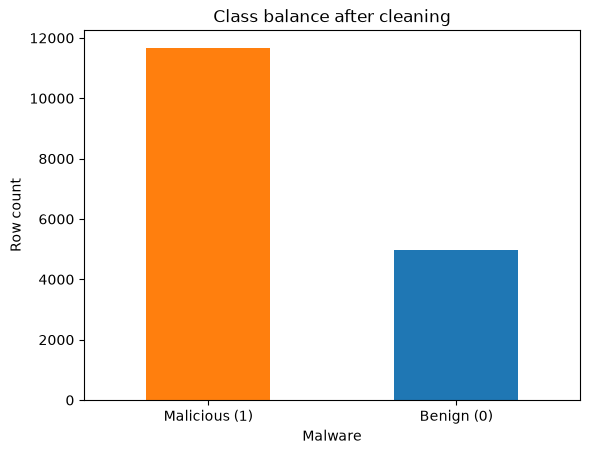

In [13]:
df[LABEL_COLUMN].value_counts().plot(kind="bar", color=["tab:orange", "tab:blue"])
plt.xticks([0, 1], ["Malicious (1)", "Benign (0)"], rotation=0)
plt.ylabel("Row count")
plt.title("Class balance after cleaning")
plt.show()

70.16% malicious versus 29.84% benign, confirmed visually here as `02_data_preparation.ipynb` computed numerically.

## Feature Distributions by Class

A look at four of the ten `CORE_TRAITS` features (the recommended training set, see `constants.py`), split by class, to see whether they visually separate malicious from benign files at all before any model is trained.

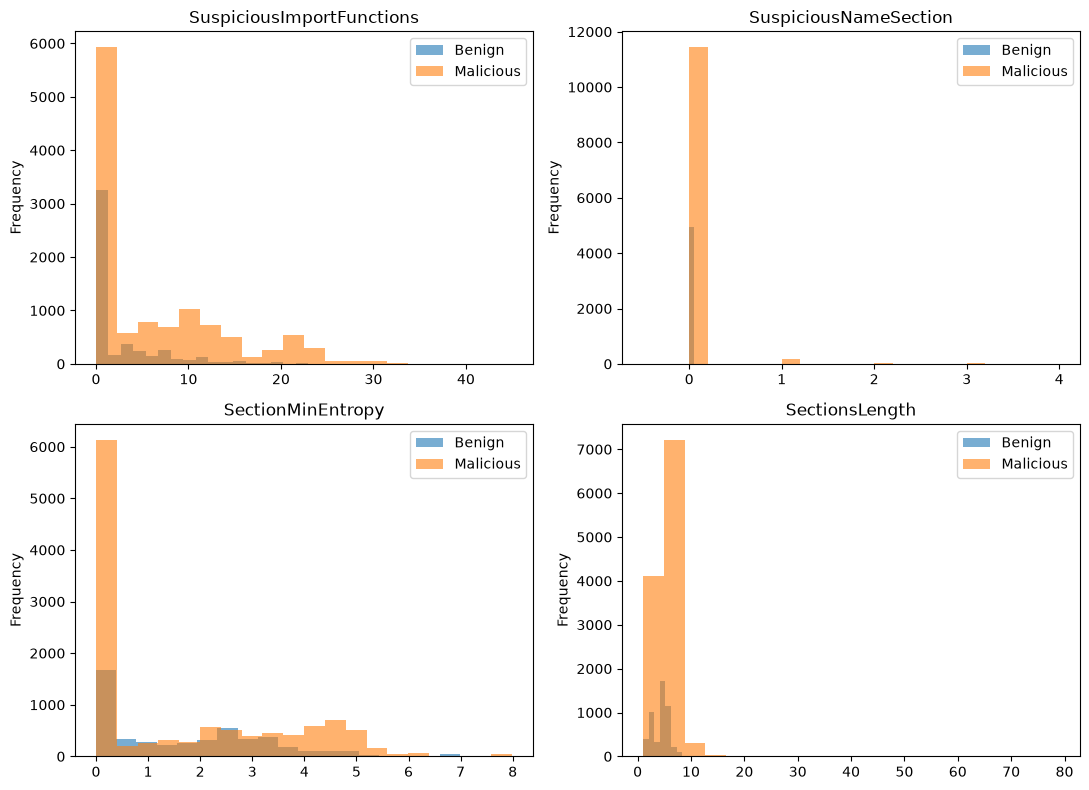

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features_to_plot = ["SuspiciousImportFunctions", "SuspiciousNameSection", "SectionMinEntropy", "SectionsLength"]
for ax, feature in zip(axes.ravel(), features_to_plot):
    df[df[LABEL_COLUMN] == 0][feature].plot(kind="hist", bins=20, alpha=0.6, ax=ax, label="Benign", color="tab:blue")
    df[df[LABEL_COLUMN] == 1][feature].plot(kind="hist", bins=20, alpha=0.6, ax=ax, label="Malicious", color="tab:orange")
    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.show()

`SuspiciousImportFunctions` and `SuspiciousNameSection` both show a visible shift toward higher counts for malicious files, in line with `extract_features.py`'s design (see `STANDARD_SECTION_NAMES` and `SUSPICIOUS_IMPORT_FUNCTIONS`). `SectionMinEntropy` and `SectionsLength` overlap more heavily between classes, suggesting they carry weaker signal on their own.

## Feature Correlation

Beyond how each `CORE_TRAITS` feature separates by class individually, it is worth checking whether any two features are simply measuring the same thing. Two perfectly correlated features add no extra information to a model, only redundancy, and are worth flagging even if a tree-based model can tolerate them without breaking.

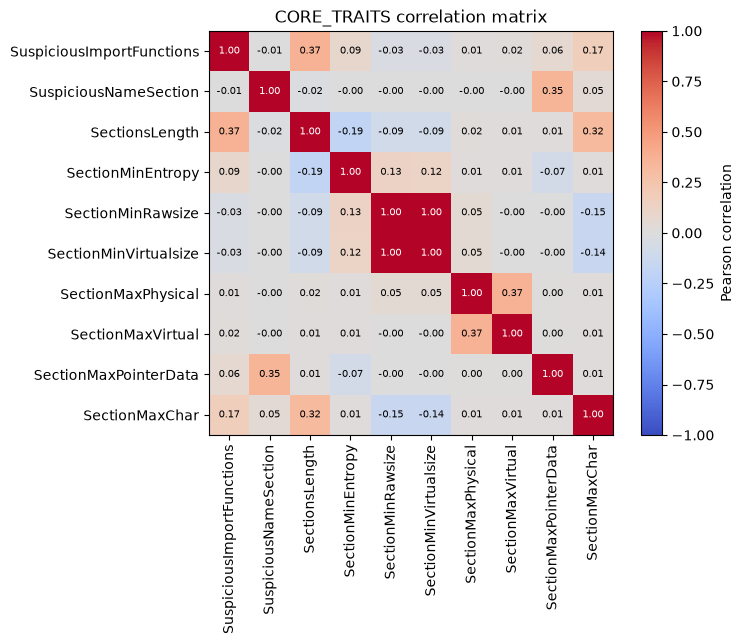

In [15]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[CORE_TRAITS].corr()
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORE_TRAITS)))
ax.set_yticks(range(len(CORE_TRAITS)))
ax.set_xticklabels(CORE_TRAITS, rotation=90)
ax.set_yticklabels(CORE_TRAITS)
for i in range(len(CORE_TRAITS)):
    for j in range(len(CORE_TRAITS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.values[i, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("CORE_TRAITS correlation matrix")
fig.tight_layout()

`SectionMinRawsize` and `SectionMinVirtualsize` are perfectly correlated (r = 1.00): for every row in this dataset, the smallest section's raw (on-disk) size and its virtual (in-memory) size are identical. This makes sense for the smallest section in files that are not packed or obfuscated, raw and virtual size usually match unless a section is compressed or padded, but it also means one of these two columns is redundant here and could be dropped without losing information. No other pair exceeds r = 0.37 (`SuspiciousImportFunctions` vs `SectionsLength`), so the remaining eight features each carry distinct signal. This redundancy is left in rather than dropped, since tree-based models split one feature at a time and are not harmed by a duplicate column the way a linear or distance-based model would be, but it is documented here as a known, low-priority simplification for future feature-engineering work.

## The DLL vs EXE Shortcut

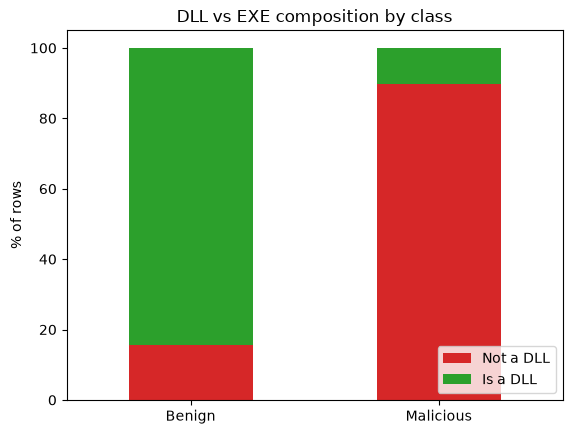

In [16]:
IMAGE_FILE_DLL = 0x2000
is_dll = (df["Characteristics"].astype(int) & IMAGE_FILE_DLL) != 0
composition = pd.crosstab(df[LABEL_COLUMN], is_dll, normalize="index") * 100
composition.columns = ["Not a DLL", "Is a DLL"]
composition.index = ["Benign", "Malicious"]
composition.plot(kind="bar", stacked=True, color=["tab:red", "tab:green"])
plt.ylabel("% of rows")
plt.title("DLL vs EXE composition by class")
plt.legend(loc="lower right")
plt.xticks(rotation=0)
plt.show()

The visual gap is large: a rule as simple as "not a DLL -> malicious" would already score close to 89% accuracy with zero real learning about malware behaviour. The next section tests whether a real model actually falls into this shortcut.

## Bias Diagnostic: Does the Model Rely on the Shortcut?

Every row is tagged "easy" (the DLL-vs-EXE shortcut agrees with the true label) or "hard" (a benign EXE or a malicious DLL, where the shortcut gives the wrong answer). The split below stratifies on label *and* group together, so hard rows are guaranteed to appear in both the training and test sets. A diagnostic XGBoost model is then trained on **all 77 features on purpose**, including the raw `Characteristics` field, specifically to check whether it *would* lean on the shortcut if it could.

In [17]:
# Tag every row "easy" (shortcut agrees with the true label) or "hard" (disagrees)
malicious = df[LABEL_COLUMN] == 1
df["group"] = "easy"
df.loc[(~malicious) & (~is_dll), "group"] = "hard"
df.loc[malicious & is_dll, "group"] = "hard"
print(df.groupby([LABEL_COLUMN, "group"]).size())

Malware  group
0        easy      4185
         hard       777
1        easy     10478
         hard      1187
dtype: int64


In [18]:
# Stratify on label + group combined, so hard rows land in both splits
df["_strata"] = df[LABEL_COLUMN].astype(str) + "_" + df["group"]
strata_counts = df["_strata"].value_counts()
usable = df[df["_strata"].isin(strata_counts[strata_counts >= 2].index)]
train_df, test_df = train_test_split(usable, test_size=0.3, stratify=usable["_strata"], random_state=RANDOM_STATE)

# Trained on ALL 77 features, including Characteristics, to see if the shortcut gets used
diagnostic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.1, eval_metric="logloss", random_state=RANDOM_STATE)),
])
diagnostic_pipeline.fit(train_df[ORDER_OF_FEATURES], train_df[LABEL_COLUMN])
test_df = test_df.copy()
test_df["pred"] = diagnostic_pipeline.predict(test_df[ORDER_OF_FEATURES])

In [19]:
easy = test_df[test_df["group"] == "easy"]
hard = test_df[test_df["group"] == "hard"]
print(f"Overall accuracy: {accuracy_score(test_df[LABEL_COLUMN], test_df['pred']):.4f}")
print(f"Easy subset accuracy: {accuracy_score(easy[LABEL_COLUMN], easy['pred']):.4f}")
print(f"Hard subset accuracy: {accuracy_score(hard[LABEL_COLUMN], hard['pred']):.4f}")

Overall accuracy: 0.9908
Easy subset accuracy: 0.9961
Hard subset accuracy: 0.9508


Overall accuracy (99.08%) and easy-subset accuracy (99.61%) are both high, but that alone would not prove the model learned anything beyond the shortcut, since easy rows are exactly where the shortcut already gives the right answer. The hard subset is the number that matters: 95.08% accuracy, far above the 50% a shortcut-only model would score there, meaning the model has learned genuine structural signal beyond "is this a DLL", even though it was allowed to see `Characteristics` freely here.

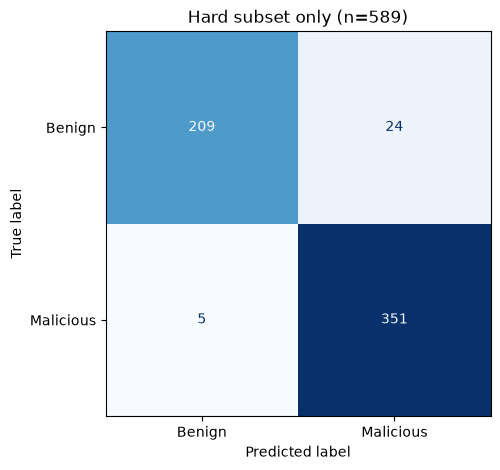

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    hard[LABEL_COLUMN], hard["pred"], display_labels=["Benign", "Malicious"],
    ax=ax, colorbar=False, cmap="Blues",
)
ax.set_title(f"Hard subset only (n={len(hard)})")
plt.show()

## Why `CORE_TRAITS` Excludes Raw Header Fields

The diagnostic model above was allowed to use every raw header field, including `Characteristics`, on purpose, to measure how strong the shortcut is when available. `constants.py`'s `CORE_TRAITS` (the feature set `04_modelling_classical.ipynb` and `05_modelling_mlp.ipynb` actually train on) deliberately excludes `Characteristics` and every other raw header/directory field, keeping only behavioural traits (suspicious imports, odd section naming, section entropy and size). This removes the shortcut at the source, rather than trusting a model not to lean on it.

## Summary

- Visualised the class balance (70.16% malicious / 29.84% benign after cleaning) and four `CORE_TRAITS` feature distributions by class; `SuspiciousImportFunctions` and `SuspiciousNameSection` show the clearest separation.
- Confirmed visually that 84.2% of benign rows are DLLs versus only 8.8% of malicious rows, a shortcut strong enough to reach ~89% accuracy alone.
- Checked pairwise correlation across all 10 `CORE_TRAITS` features: `SectionMinRawsize` and `SectionMinVirtualsize` are perfectly correlated (r = 1.00), a redundant pair worth noting for future feature-engineering, no other pair exceeds r = 0.37.
- Ran a bias diagnostic: split the data so "hard" rows (benign EXEs, malicious DLLs) appear in both train and test, then trained an XGBoost model on all 77 features on purpose. Hard-subset accuracy came out to 95.08%, far above the 50% a shortcut-only model would score, confirming genuine signal exists beyond the DLL/EXE shortcut.
- This is why `CORE_TRAITS` (used from `04_modelling_classical.ipynb` onward) excludes `Characteristics` and every other raw header/directory field: removing the shortcut at the feature level, rather than relying on a model not to use it.